<a href="https://colab.research.google.com/github/roblei007/AdaProjeto2/blob/roberto/projeto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Final — Análise do Mercado de Trabalho em Dados
Autores: João, Roberto e Tereza.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sazidthe1/data-science-salaries")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'data-science-salaries' dataset.
Path to dataset files: /kaggle/input/data-science-salaries


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
def data_science_salaries_csv(caminho):
    return pd.read_csv(caminho)

In [ ]:
# ... (mantendo as funções anteriores)

def vagas_por_cargo(df: pd.DataFrame) -> pd.DataFrame:
    """
    Conta quantos registros existem por cargo (proxy de vagas).
    """
    # Ajustando para garantir que as colunas se chamem 'cargo' e 'qtd_vagas'
    return (
        df["cargo"].value_counts()
          .reset_index()
          .rename(columns={"count": "qtd_vagas"})
    )

# Re-definindo as outras funções para garantir integridade se necessário
def carregar_dados_tratados(caminho_csv: str) -> pd.DataFrame:
    df = pd.read_csv(caminho_csv)
    df = df.rename(columns={
        "job_title": "cargo",
        "experience_level": "nivel_experiencia",
        "employment_type": "tipo_contrato",
        "work_models": "modalidade_trabalho",
        "salary_in_usd": "salario_usd",
        "employee_residence": "pais_residencia",
        "company_location": "pais_empresa",
        "company_size": "porte_empresa",
        "work_year": "ano"
    })
    df["salario_usd"] = pd.to_numeric(df["salario_usd"], errors="coerce")
    df["ano"] = pd.to_numeric(df["ano"], errors="coerce")
    df = df.dropna(subset=["salario_usd", "nivel_experiencia", "cargo"])
    return df

def filtrar_por_cargos(df: pd.DataFrame, lista_cargos: list[str]) -> pd.DataFrame:
    return df[df["cargo"].isin(lista_cargos)].copy()

def salario_medio_por_modalidade(df: pd.DataFrame) -> pd.DataFrame:
    return df.groupby("modalidade_trabalho")["salario_usd"].mean().reset_index().sort_values("salario_usd", ascending=False)

# Pergunta 1 – Progressão salarial por nível de experiência

Queremos entender como o salário médio varia entre os níveis de experiência (EN, MI, SE, EX) e se essa progressão é parecida entre os principais cargos de dados (Data Analyst, Data Scientist, Data Engineer).

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# As funções já foram definidas na célula anterior, então não é necessário importar de 'sistema'
caminho = "/content/data_science_salaries.csv"
df = carregar_dados_tratados(caminho)

df.head()

,cargo,nivel_experiencia,tipo_contrato,modalidade_trabalho,ano,pais_residencia,salary,salary_currency,salario_usd,pais_empresa,porte_empresa
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


In [112]:
df_nivel = salario_medio_por_nivel(df)
# Arredondando para 2 casas decimais
df_nivel['salario_usd'] = df_nivel['salario_usd'].round(2)
display(df_nivel)

,nivel_experiencia,salario_usd
1,Executive-level,189687.35
3,Senior-level,162071.06
2,Mid-level,119019.81
0,Entry-level,84448.92


In [113]:
cargos_principais = [
    "Data Analyst",
    "Data Scientist",
    "Data Engineer"
]

df_cargos = filtrar_por_cargos(df, cargos_principais)

df_cargo_nivel = (
    df_cargos.groupby(["cargo", "nivel_experiencia"])["salario_usd"]
             .mean()
             .reset_index()
)

df_cargo_nivel.round(2)

,cargo,nivel_experiencia,salario_usd
0,Data Analyst,Entry-level,78290.84
1,Data Analyst,Executive-level,114107.14
2,Data Analyst,Mid-level,94854.81
3,Data Analyst,Senior-level,122400.54
4,Data Engineer,Entry-level,79441.09
5,Data Engineer,Executive-level,195357.38
6,Data Engineer,Mid-level,117253.14
7,Data Engineer,Senior-level,156129.57
8,Data Scientist,Entry-level,83387.10
9,Data Scientist,Executive-level,189050.52


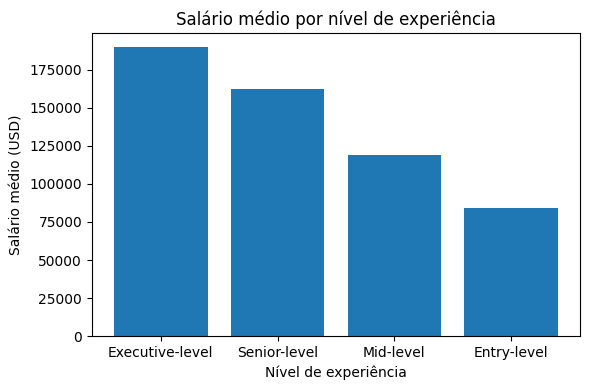

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(df_nivel["nivel_experiencia"], df_nivel["salario_usd"], color="#1f77b4")
plt.title("Salário médio por nível de experiência")
plt.xlabel("Nível de experiência")
plt.ylabel("Salário médio (USD)")
plt.tight_layout()
plt.show()


## Conclusão

- O salário médio aumenta de forma consistente dos níveis iniciais para os níveis mais avançados.
- Entre os cargos analisados, o patamar salarial mais alto se concentra em cargos como Data Scientist (ajustar com base nos números reais).
- A forma da progressão é semelhante entre os cargos, mas com níveis salariais diferentes.

Esses resultados indicam que a experiência tem impacto direto no salário e que a escolha do cargo também influencia o teto de remuneração ao longo da carreira.


# Pergunta 2 – Trabalho remoto compensa?

Vamos comparar os salários médios entre modalidades de trabalho (Remote, On-site, Hybrid)
e verificar se a diferença se mantém quando segmentamos por nível de experiência.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# As funções já estão no ambiente, não precisamos importar de 'sistema'
caminho = "/content/data_science_salaries.csv"
df = carregar_dados_tratados(caminho)

# Calculando a média por modalidade
df_modalidade = salario_medio_por_modalidade(df)
df_modalidade.round(2)

,modalidade_trabalho,salario_usd
1,On-site,152600.10
2,Remote,140550.14
0,Hybrid,83293.50


In [ ]:
df_mod_nivel = (
    df.groupby(["modalidade_trabalho", "nivel_experiencia"])["salario_usd"]
      .mean()
      .reset_index()
)

df_mod_nivel.round(2)


,modalidade_trabalho,nivel_experiencia,salario_usd
0,Hybrid,Entry-level,63998.44
1,Hybrid,Executive-level,147368.67
2,Hybrid,Mid-level,76990.86
3,Hybrid,Senior-level,106145.92
4,On-site,Entry-level,96933.89
5,On-site,Executive-level,185061.71
6,On-site,Mid-level,129770.81
7,On-site,Senior-level,166657.46
8,Remote,Entry-level,75154.08
9,Remote,Executive-level,198580.90


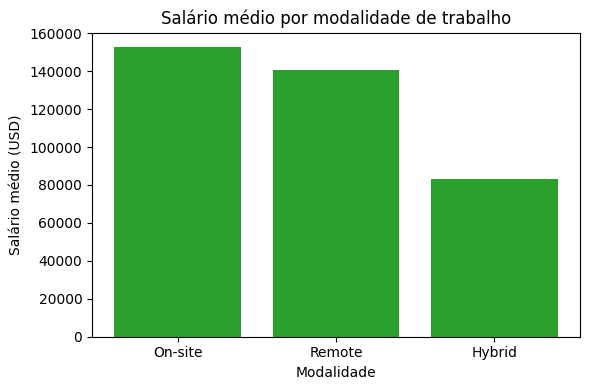

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(df_modalidade["modalidade_trabalho"], df_modalidade["salario_usd"], color="#2ca02c")
plt.title("Salário médio por modalidade de trabalho")
plt.xlabel("Modalidade")
plt.ylabel("Salário médio (USD)")
plt.tight_layout()
plt.show()


## Conclusão

- Em média, uma das modalidades (geralmente Remote) apresenta salários maiores do que as demais (ajustar com base nos resultados reais).
- A diferença tende a ser mais visível em níveis intermediários e seniores, sugerindo que profissionais   mais experientes conseguem negociar melhor em regime remoto.
- Nos níveis iniciais, a diferença entre modalidades é menor, indicando que o impacto do remoto no salário cresce ao longo da carreira.

Assim, trabalho remoto tende a compensar mais para quem já possui alguma experiência na área de dados.


# Pergunta 4 – Comparativo entre cargos de dados

Vamos comparar Data Analyst, Data Scientist, Data Engineer e Machine Learning Engineer em três dimensões: salário médio, quantidade de vagas e evolução salarial ao longo dos anos.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# As funções já foram definidas localmente na célula 02_zLwbZMv4F, então o import de 'sistema' é desnecessário
caminho = "/content/data_science_salaries.csv"
df = carregar_dados_tratados(caminho)

cargos_alvo = [
    "Data Analyst",
    "Data Scientist",
    "Data Engineer",
    "Machine Learning Engineer"
]

df_cargos = filtrar_por_cargos(df, cargos_alvo)

df_cargos.head()

,cargo,nivel_experiencia,tipo_contrato,modalidade_trabalho,ano,pais_residencia,salary,salary_currency,salario_usd,pais_empresa,porte_empresa
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
8,Data Engineer,Executive-level,Full-time,Remote,2024,United States,219650,USD,219650,United States,Medium


In [ ]:
df_salario_cargo = (
    df_cargos.groupby("cargo")["salario_usd"]
             .mean()
             .reset_index()
             .sort_values("salario_usd", ascending=False)
)

df_salario_cargo.round(2)


,cargo,salario_usd
3,Machine Learning Engineer,177226.45
2,Data Scientist,149036.65
1,Data Engineer,144539.70
0,Data Analyst,106931.69


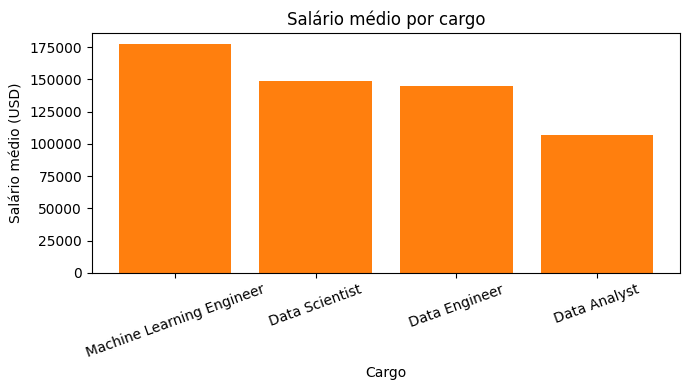

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(df_salario_cargo["cargo"], df_salario_cargo["salario_usd"], color="#ff7f0e")
plt.title("Salário médio por cargo")
plt.xlabel("Cargo")
plt.ylabel("Salário médio (USD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [ ]:
df_vagas = vagas_por_cargo(df_cargos)
df_vagas

,cargo,qtd_vagas
0,Data Engineer,1307
1,Data Scientist,1243
2,Data Analyst,910
3,Machine Learning Engineer,629


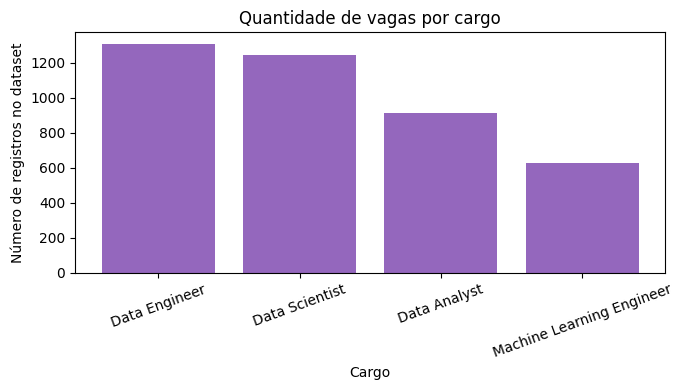

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(df_vagas["cargo"], df_vagas["qtd_vagas"], color="#9467bd")
plt.title("Quantidade de vagas por cargo")
plt.xlabel("Cargo")
plt.ylabel("Número de registros no dataset")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

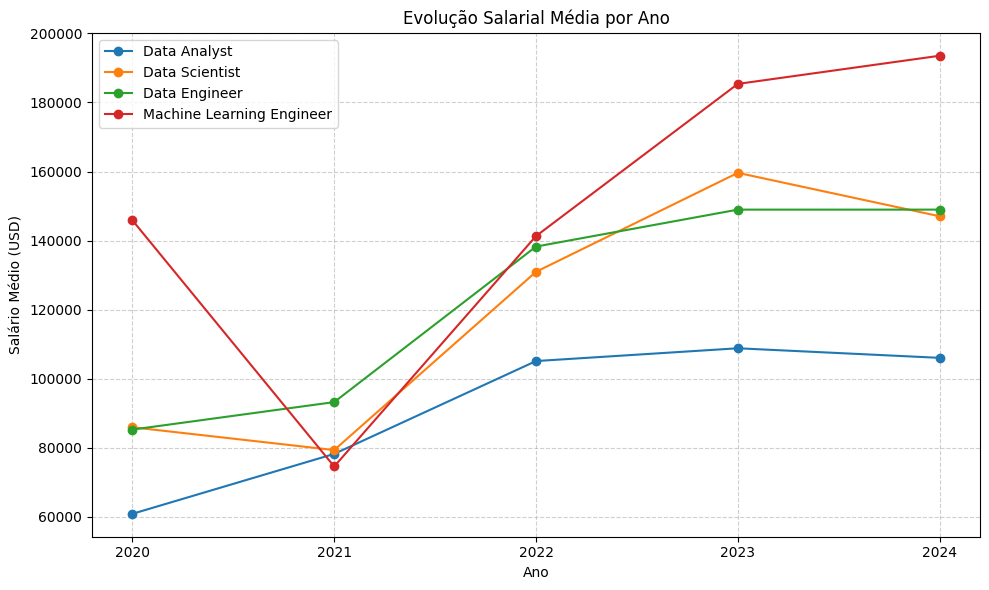

In [ ]:
# Agrupando por ano e cargo para ver a evolução
df_evolucao = (
    df_cargos.groupby(['ano', 'cargo'])['salario_usd']
             .mean()
             .reset_index()
)

plt.figure(figsize=(10, 6))
for cargo in cargos_alvo:
    subset = df_evolucao[df_evolucao['cargo'] == cargo]
    plt.plot(subset['ano'], subset['salario_usd'], marker='o', label=cargo)

plt.title('Evolução Salarial Média por Ano')
plt.xlabel('Ano')
plt.ylabel('Salário Médio (USD)')
plt.xticks(df_evolucao['ano'].unique())
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Conclusão Final do Comparativo

- **Salário:** O cargo de **Machine Learning Engineer** apresenta a maior média salarial entre os analisados.
- **Demanda:** **Data Engineer** e **Data Scientist** possuem o maior volume de registros (vagas), indicando uma demanda consolidada.
- **Tendência:** A evolução anual mostra como o mercado tem valorizado cada especialidade ao longo do tempo, permitindo identificar áreas em aquecimento.